### feature selection(변수 선택법)
* 필요한 변수만 선택하여 모델의 예측력을 높이거나 과적합을 줄이는 것
* 알고리즘의 정확도가 유사하다면 변수의 개수가 적을수록 속도가 빠르다
* 방법
    - L1(라쏘)을 이용하여 영향력이 0(작은)값을 빼는 방법
    - 단변량(filter) : 특정 컬럼이 또 다른 컬럼과 상관관계가 있는지 확인하는 방법
    - 전진/후진 선택법(wrapper) : 컬럼을 하나씩 추가하며 점수 확인 / 하나씩 빼며 점수 확인
    - RFE : 사이킷런에서 제공하는 라이브러리를 이용하여 변수의 중요도를 확인하여 변수를 선택하는 방법
    - embed(임베드) : 알고리즘의 성질 이용
        - 알고리즘 내부에서 각 feature 구송 요소들이 얼마나 사용 되었는지를 알아보는 방식
        - 알고리즘들을 이용해 변수의 중요도를 파악, 중요도 낮은 컬럼은 지울 수 있다
        - 참고
            * RFE와 embed 방식은 특정 알고리즘에 존재하며, 해당 방식을 사용할 수 없는 알고리즘들이 존재한다.(KNN, SVR(kernel=rbf)등 사용 못함)
            * Tree계열 알고리즘들은 사용 가능하다(Random Forest, Decision Tree 등)

In [1]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

In [2]:
df = pd.read_csv('../data_set/6.회귀/data_cleaning.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,temp_int
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,9
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,9
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,9
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,9
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,9


In [3]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour', 'temp_int'],
      dtype='object')

In [4]:
features = [ 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'

In [5]:
X, y = df[features],df[label]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
                train_test_split(X, y, test_size=0.3, random_state=156)

#### 모델 생성

In [8]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
print("train : ", model.score(X_train, y_train) )
print("test : ", model.score(X_test, y_test) )

train :  0.991680219960506
test :  0.9452734968650641


#### 단변량(filter)
- feature들의 상관관계가 높은 건 제거

<Axes: xlabel='temp', ylabel='atemp'>

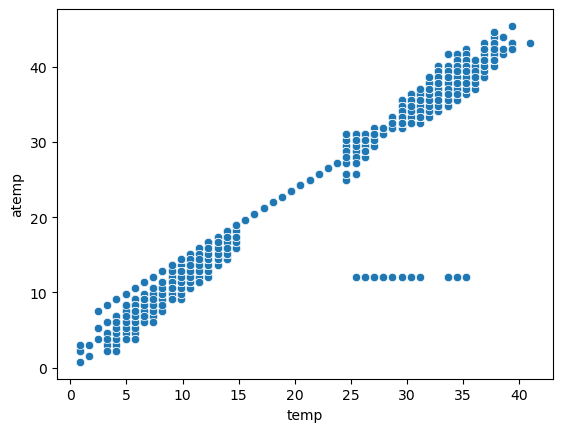

In [9]:
# 두 변수가 밀접한 속성을 가지고 있다면 일렬로 만들어지게 된다
import seaborn as sns
sns.scatterplot(data=df, x='temp', y='atemp')

In [10]:
df.corr(numeric_only=True) # 숫자형 칼럼들끼리 상관관계 계산(corr: 상관계수 계산)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,temp_int
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439,-0.004797,0.971524,0.001729,-0.006546,0.257917
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393,0.012021,0.001731,-0.015877,-0.000354,0.000192
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594,-0.002482,-0.003394,0.009829,0.002780,0.029603
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655,-0.012548,0.012144,-0.007890,-0.022740,-0.054556
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454,0.061226,0.257589,0.015551,0.145430,0.999313
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784,0.058540,0.264173,0.011866,0.140343,0.984431
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371,-0.078606,0.204537,-0.011335,-0.278011,-0.064205
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369,-0.015221,-0.150192,0.036157,0.146631,-0.017660
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414,0.145241,0.092722,0.014109,0.302045,0.467047
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948,0.264265,0.169451,0.019111,0.380540,0.318048


In [11]:
import matplotlib.pyplot as plt

<Axes: >

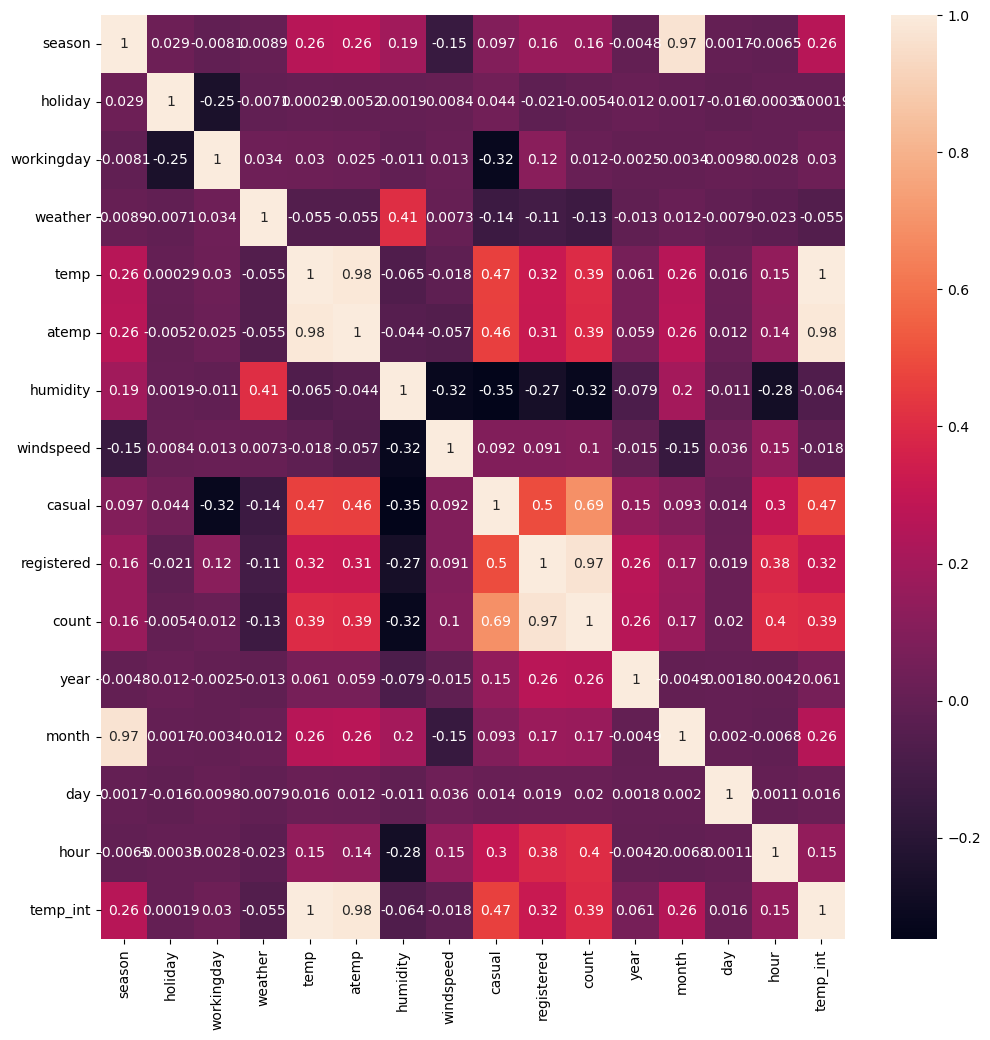

In [12]:
plt.subplots(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True), annot=True)

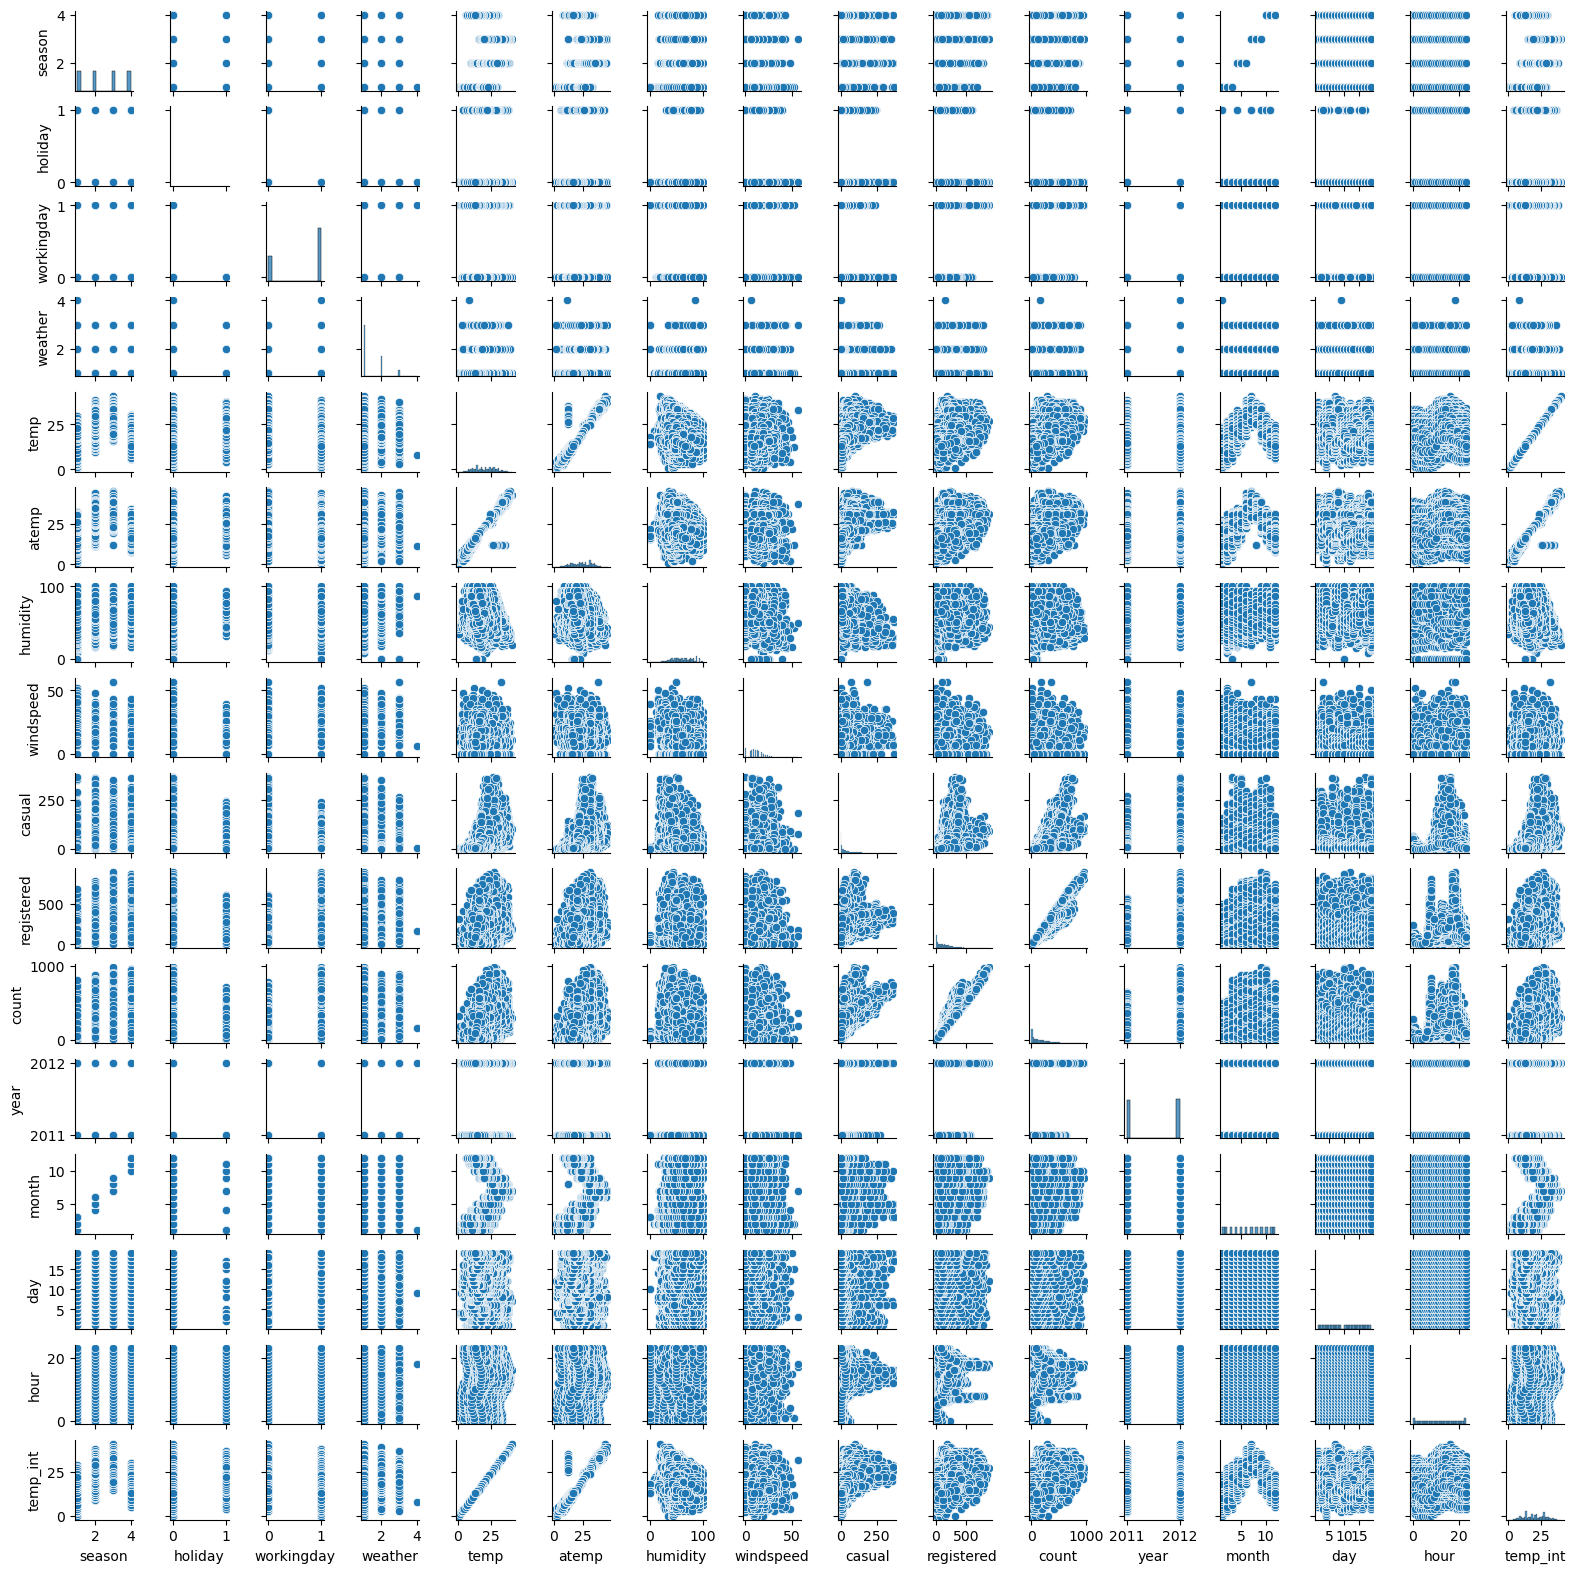

In [13]:
sns.pairplot(df, height=1)
plt.show()

In [16]:
print("이전 train : ", model.score(X_train, y_train) )
print("이전 test : ", model.score(X_test, y_test) )

이전 train :  0.9915446038767253
이전 test :  0.9405389974546776


In [23]:
f = [ 'season', 'holiday', 'workingday', 'weather', 'temp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'
X, y = df[f],df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
print("train : ", model.score(X_train, y_train) )
print("test : ", model.score(X_test, y_test) )

train :  0.9915869001258867
test :  0.9444170478674703


#### wrapper(전진/후진 선택)

In [40]:
#전진 선택

In [19]:
from itertools import combinations

In [20]:
sample_bag = [1,2,3,4]
for c in combinations(sample_bag, 2):
    print(c, type(c))

(1, 2) <class 'tuple'>
(1, 3) <class 'tuple'>
(1, 4) <class 'tuple'>
(2, 3) <class 'tuple'>
(2, 4) <class 'tuple'>
(3, 4) <class 'tuple'>


In [25]:
all_result = []
for c in combinations(f, 2):
    #print(c)
    X_train, X_test, y_train, y_test = train_test_split(df[list(c)], df['count'], test_size=0.3)

    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    sub_result = {"combination":str(c), "train":train_score, "test":test_score}
    all_result.append(sub_result)
result_df = pd.DataFrame(all_result).sort_values(by="test")
result_df.tail()

,combination,train,test
39,"('temp', 'hour')",0.682289,0.601518
9,"('season', 'hour')",0.612353,0.603122
53,"('month', 'hour')",0.631003,0.618836
51,"('year', 'hour')",0.619423,0.619843
26,"('workingday', 'hour')",0.659344,0.640964


In [37]:
best_f = ['workingday', 'hour']
f = [ 'season', 'holiday', 'weather', 'temp','humidity', 'windspeed', 'year', 'month', 'day']

In [30]:
for c in f:
    best_f.append(c)
    print(best_f)
    best_f.pop()

['workingday', 'hour', 'season']
['workingday', 'hour', 'holiday']
['workingday', 'hour', 'weather']
['workingday', 'hour', 'temp']
['workingday', 'hour', 'humidity']
['workingday', 'hour', 'windspeed']
['workingday', 'hour', 'year']
['workingday', 'hour', 'month']
['workingday', 'hour', 'day']


In [38]:
all_result = []
for c in f:
    best_f.append(c)
    
    X_train, X_test, y_train, y_test = train_test_split(df[best_f], df['count'], test_size=0.3)

    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    sub_result = {"best f":best_f.copy(), "train":train_score, "test":test_score}
    all_result.append(sub_result)
    best_f.pop()

In [39]:
result_df = pd.DataFrame(all_result).sort_values(by="test")
result_df.tail()

,best f,train,test
2,"[workingday, hour, weather]",0.689423,0.675367
3,"[workingday, hour, temp]",0.827938,0.734211
7,"[workingday, hour, month]",0.787594,0.736676
0,"[workingday, hour, season]",0.753162,0.754709
6,"[workingday, hour, year]",0.767842,0.764620


In [44]:
#후진 선택법
#모든 feature를 추가 후 하나씩 빼면서 확인

In [50]:
f = [ 'season', 'holiday', 'workingday', 'weather', 'temp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'

In [54]:
all_result = []
for item in combinations(f, len(f) - 1):
    #print(c)
    target = list(item)
    
    X_train, X_test, y_train, y_test = train_test_split(df[target], df['count'], test_size=0.3)

    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    drop = set(f) - set(target)
    
    sub_result = {"drop feature":drop.pop(), "train":train_score, "test":test_score}
    all_result.append(sub_result)

In [55]:
result_df = pd.DataFrame(all_result).sort_values(by="test")
result_df

,drop feature,train,test
0,hour,0.908476,0.428615
8,workingday,0.971492,0.800259
3,year,0.980804,0.854076
6,temp,0.990949,0.926633
7,weather,0.990734,0.928962
9,holiday,0.991642,0.937484
5,humidity,0.990099,0.937820
1,day,0.991755,0.939241
2,month,0.991039,0.940583
4,windspeed,0.991979,0.940715


In [56]:
f = ['workingday', 'weather', 'temp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'
X_train, X_test, y_train, y_test = train_test_split(df[f], df[label], test_size=0.3)

model = RandomForestRegressor()
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

In [57]:
print(train_score)
print(test_score)

0.9912428339396718
0.9406864924683437


#### RFE

In [58]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'
X_train, X_test, y_train, y_test = train_test_split(df[f], df[label], test_size=0.3)

model = RandomForestRegressor()
#model.fit(X_train, y_train)

In [59]:
from sklearn.feature_selection import RFE

In [60]:
rfe = RFE( estimator = model )
rfe.fit( X_train , y_train )
rfe_df = pd.DataFrame()
rfe_df['ranking'] = rfe.ranking_
rfe_df['features'] = X_train.columns

In [61]:
rfe_df.sort_values(by="ranking")

,ranking,features
2,1,workingday
4,1,temp
7,1,year
8,1,month
10,1,hour
5,2,humidity
3,3,weather
9,4,day
0,5,season
6,6,windspeed


In [62]:
f = ['temp', 'year', 'month', 'hour', 'workingday', 'humidity']
label = 'count'
X_train, X_test, y_train, y_test = train_test_split(df[f], df[label], test_size=0.3)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print("train : ", model.score(X_train, y_train))
print("test : ", model.score(X_test, y_test))

train :  0.9896299369636429
test :  0.9235364856297774


### 임베드 방식
- 트리계열에서 사용

In [63]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'
X_train, X_test, y_train, y_test = train_test_split(df[f], df[label], test_size=0.3)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
print(model.feature_importances_)
X_train.columns

[0.00860366 0.00153553 0.07087913 0.01675653 0.10096    0.03418797
 0.01011969 0.08323983 0.04860024 0.01315514 0.61196229]


Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity',
       'windspeed', 'year', 'month', 'day', 'hour'],
      dtype='object')

In [66]:
rfe_df = pd.DataFrame()
rfe_df["rank"] = model.feature_importances_
rfe_df["feature"] = X_train.columns

In [67]:
rfe_df.sort_values(by="rank", ascending=False) #sort_values: 데이터를 특정 기준으로 정렬

,rank,feature
10,0.611962,hour
4,0.100960,temp
7,0.083240,year
2,0.070879,workingday
8,0.048600,month
5,0.034188,humidity
3,0.016757,weather
9,0.013155,day
6,0.010120,windspeed
0,0.008604,season
